In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter


#Read raw data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

In [ ]:
#Slice the data to extract only the eastern N-S transect
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)


In [ ]:


location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-165, -115, 65, 80]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)

mapper.plot_station_locations(ax = ax, ds = ds, label = 'CTD Cast')
mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren North-South Transect')

plt.title("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations")
plt.legend()

plt.show()



In [ ]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    e_ns_cruise_transects[key] = dsops.clean_CTD_dataset(e_ns_cruise_transects[key])


year = 2013
transect = e_ns_cruise_transects[year].sortby(e_ns_cruise_transects[year]['lat'])

temp = transect['TEMP'].T


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/var/folders/61/g6_79pl163j3mj4vnjydc9bm0000gn/T/ipykernel_83732/1870416478.py:30: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title(f"{year} 140$^\circ$W Temperature Transect")
/var/folders/61/g6_79pl163j3mj4vnjydc9bm0000gn/T/ipykernel_83732/1870416478.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  field_figure = plt.figure(figsize=(12,8))


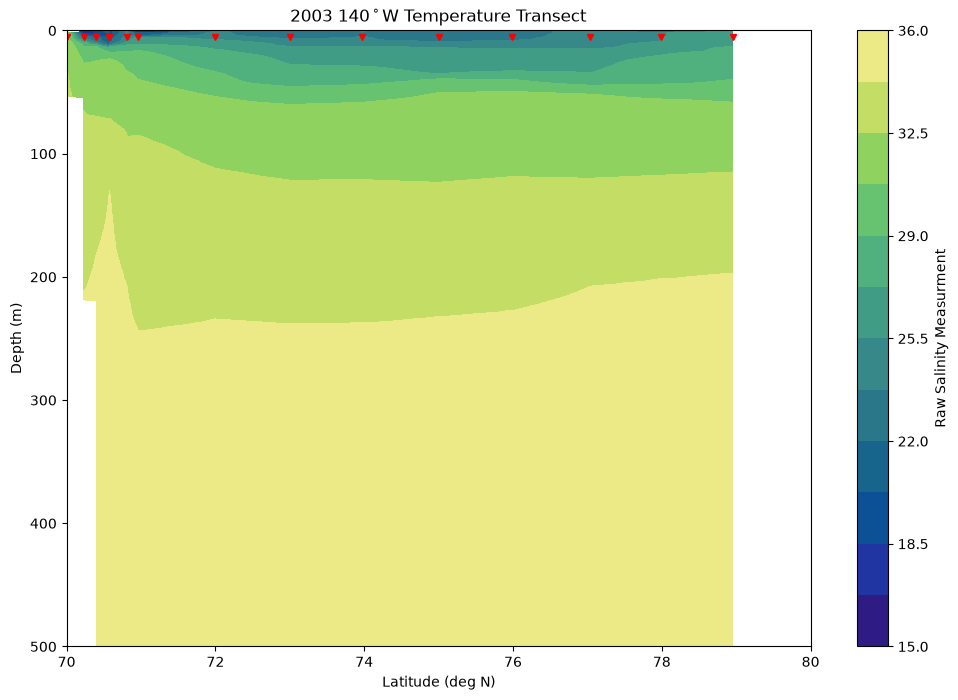

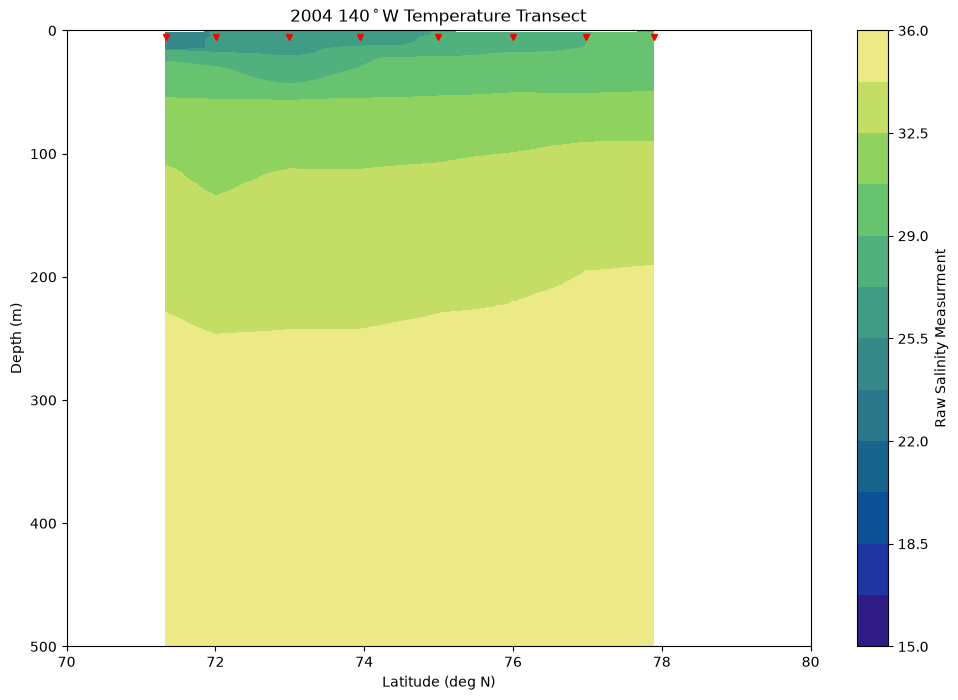

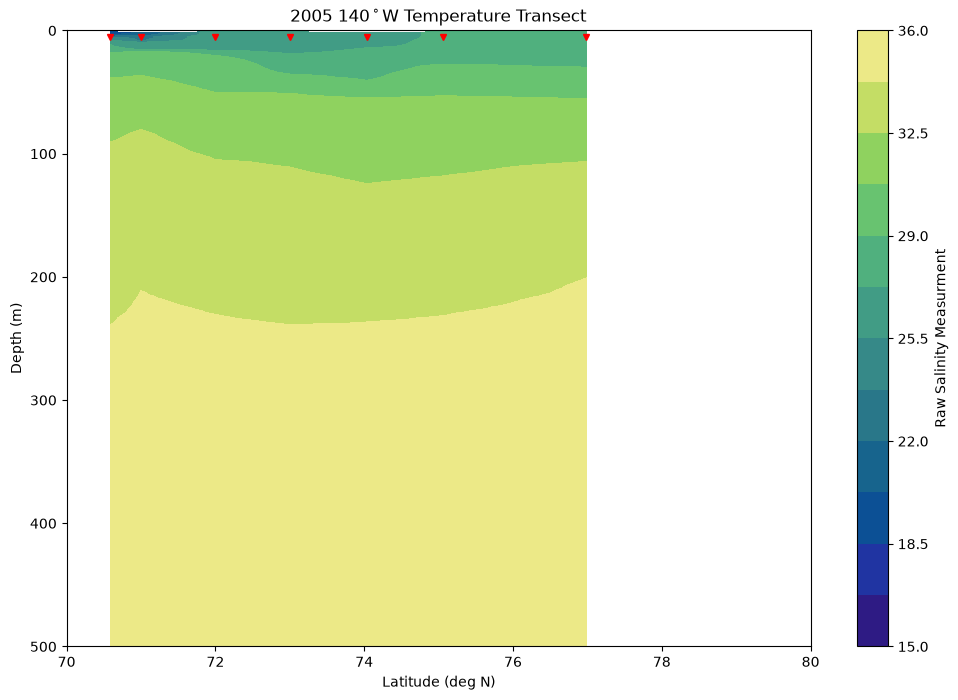

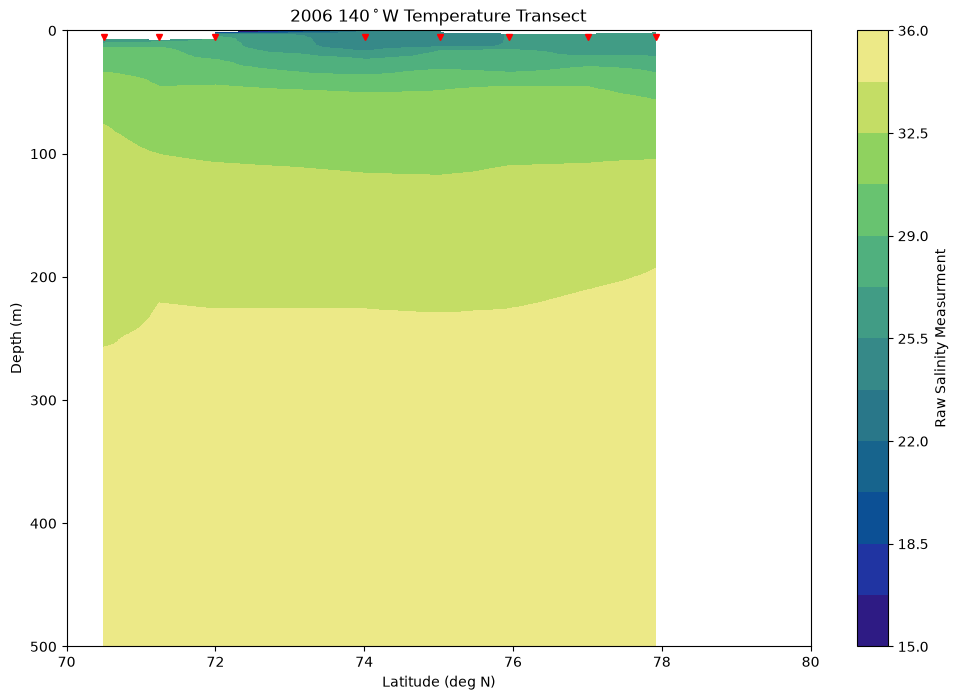

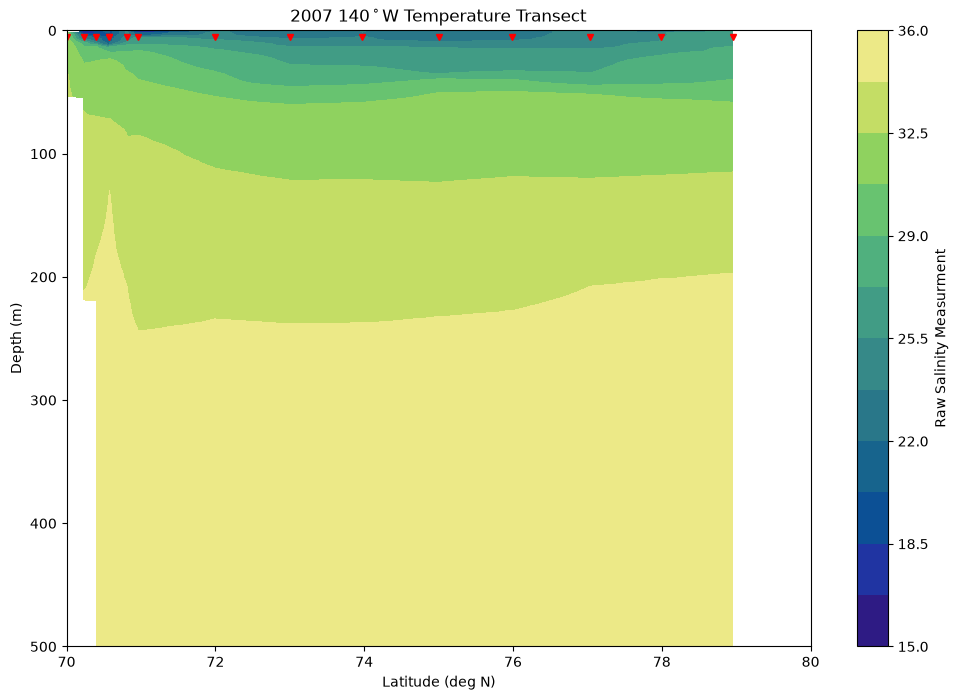

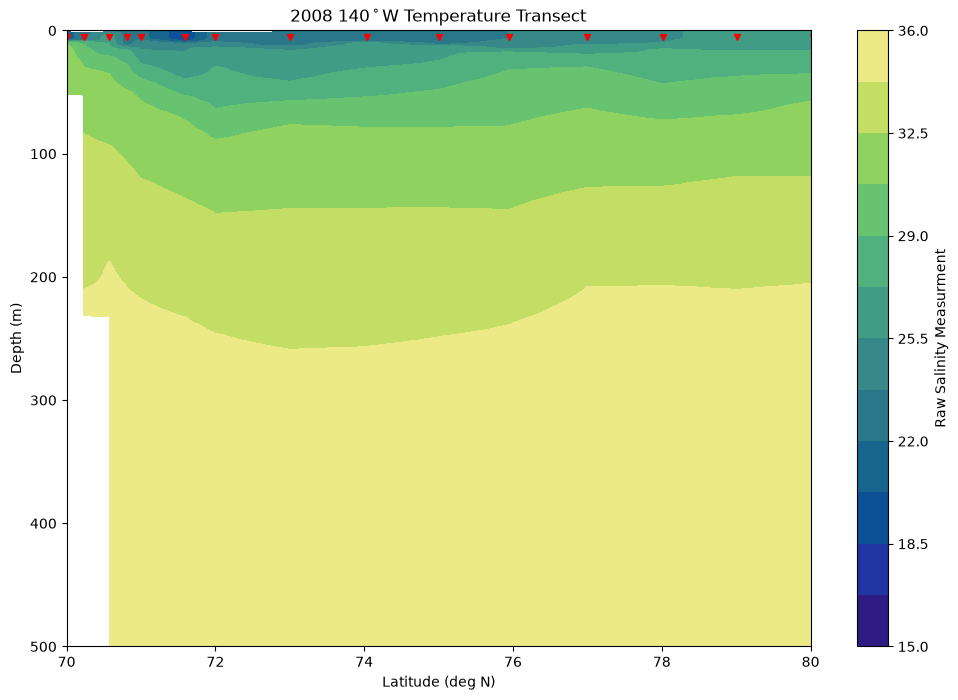

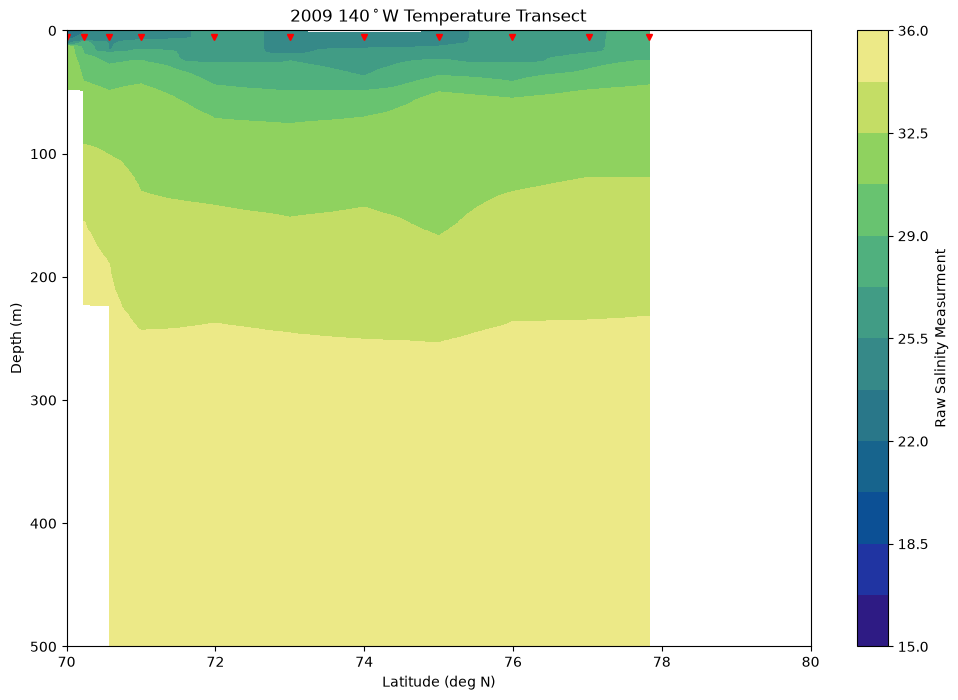

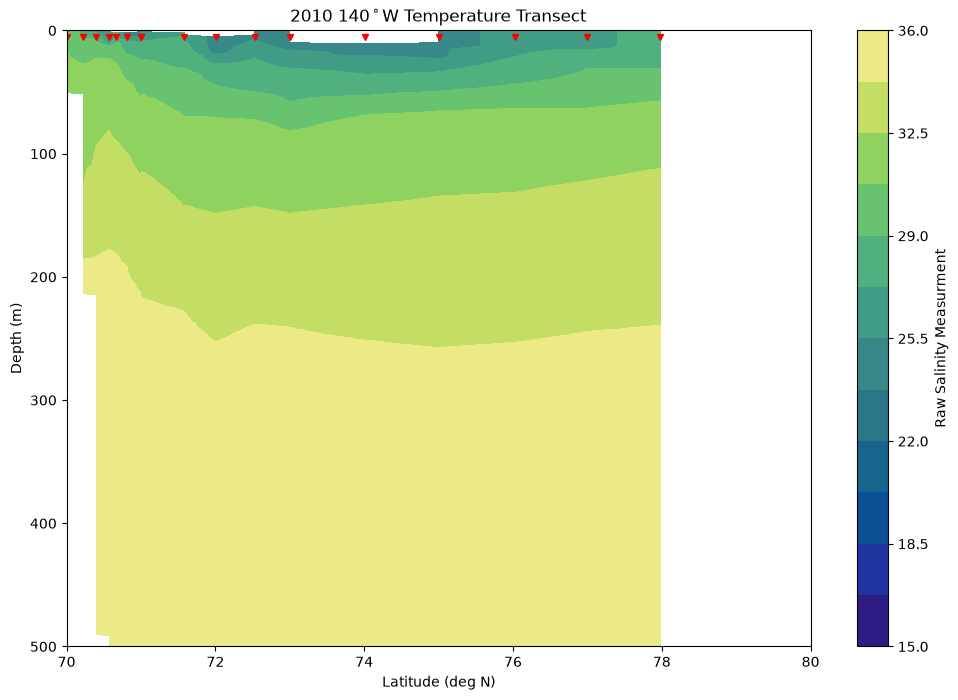

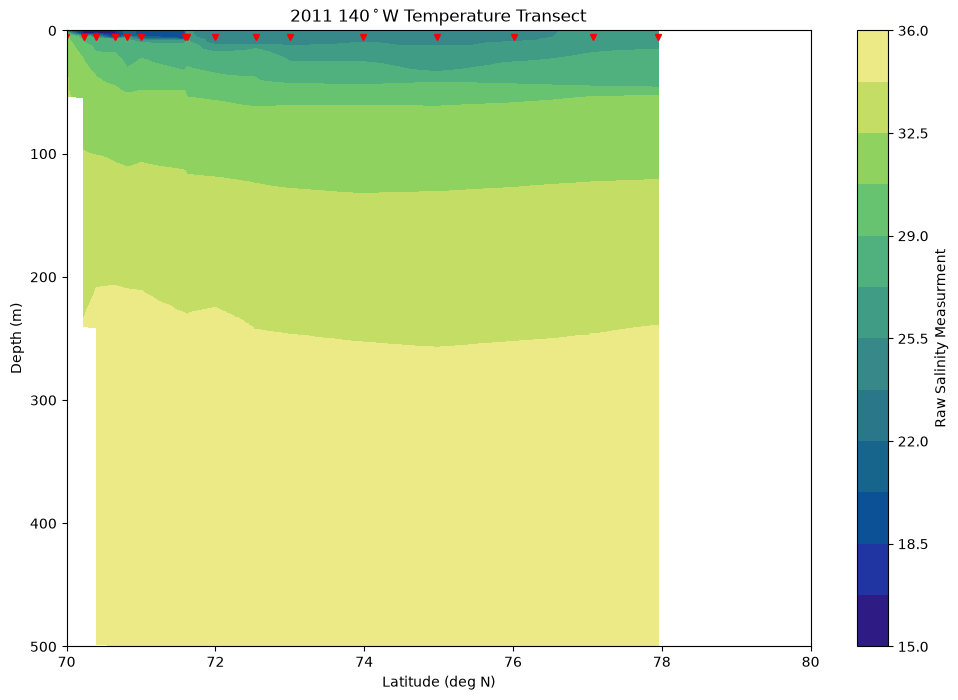

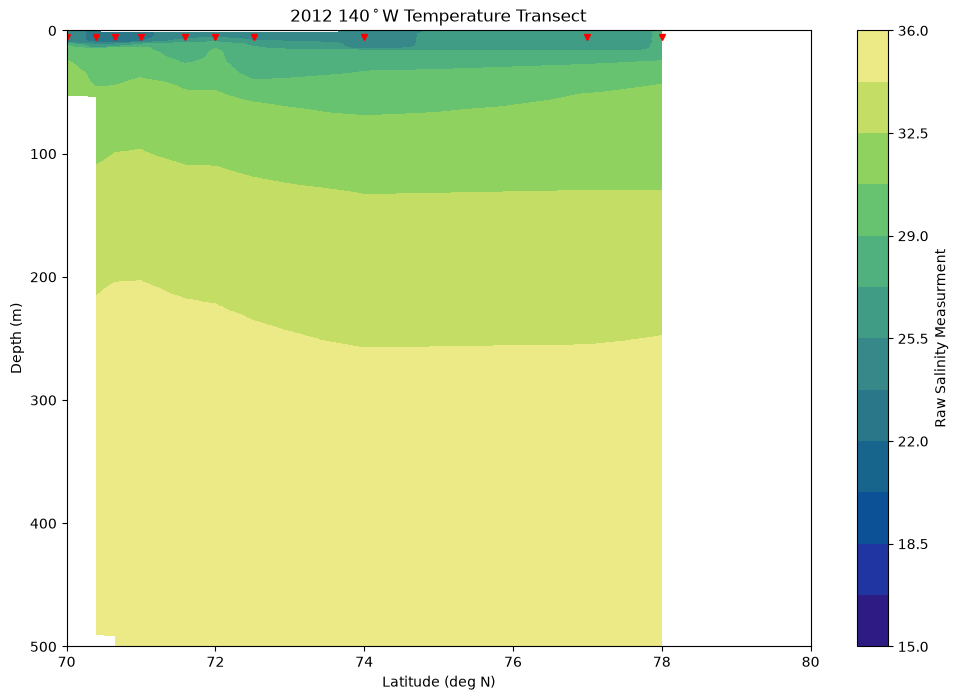

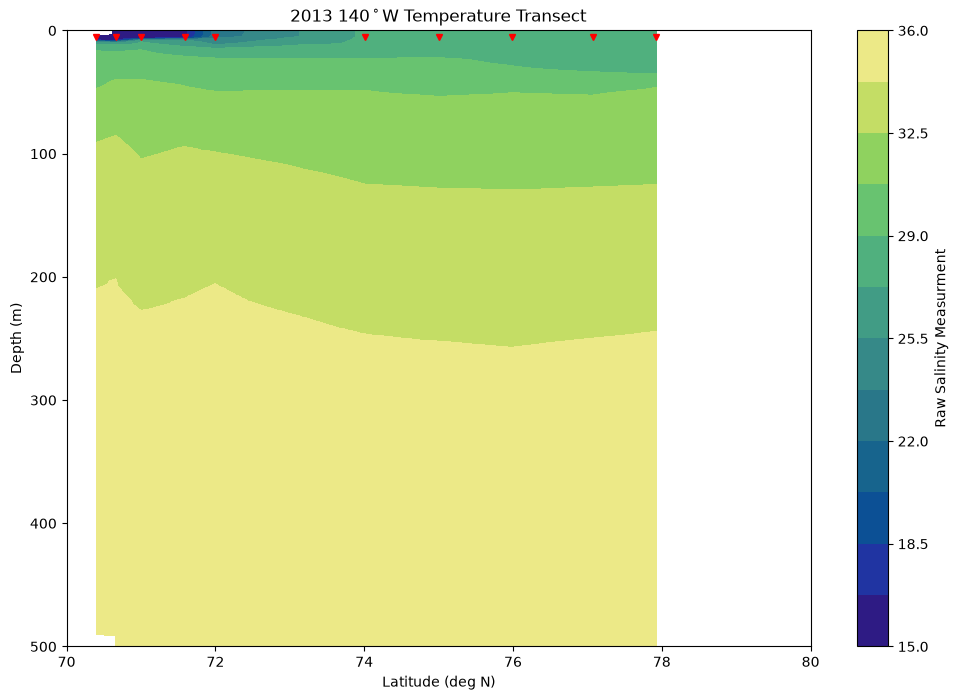

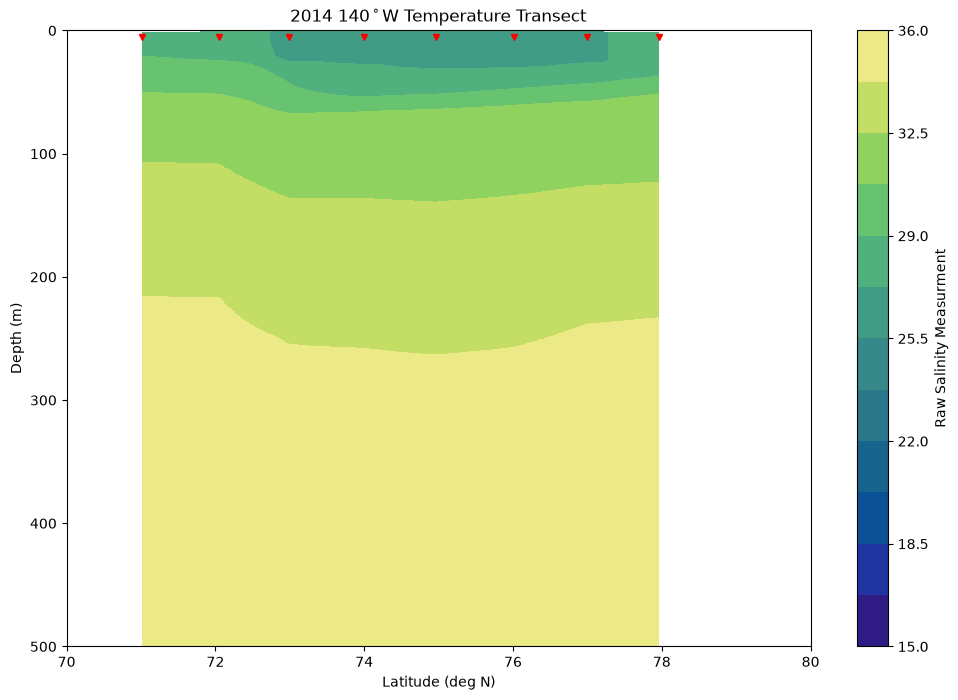

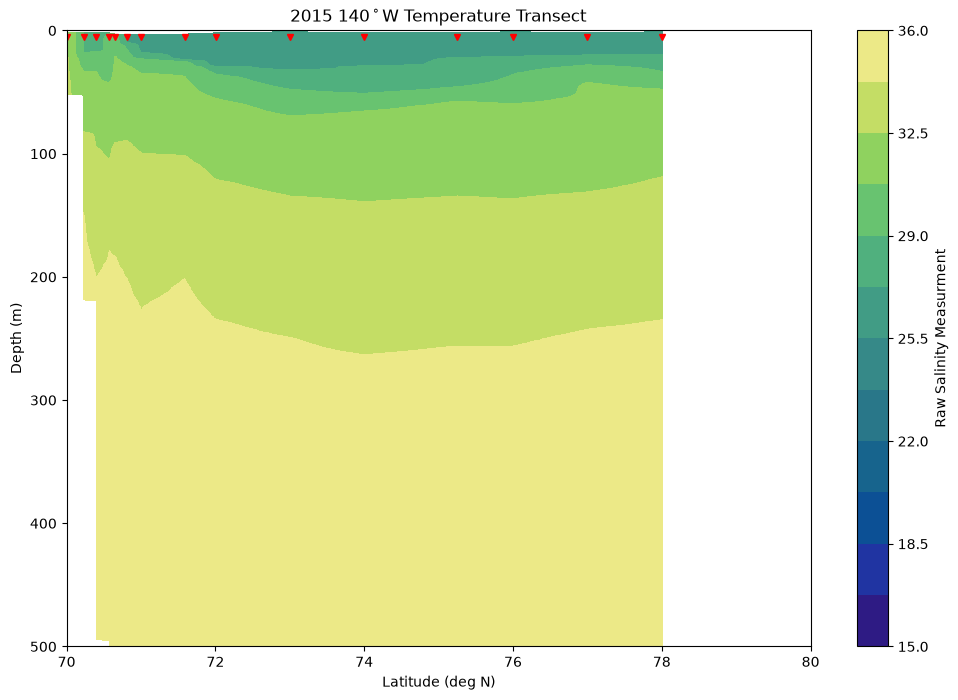

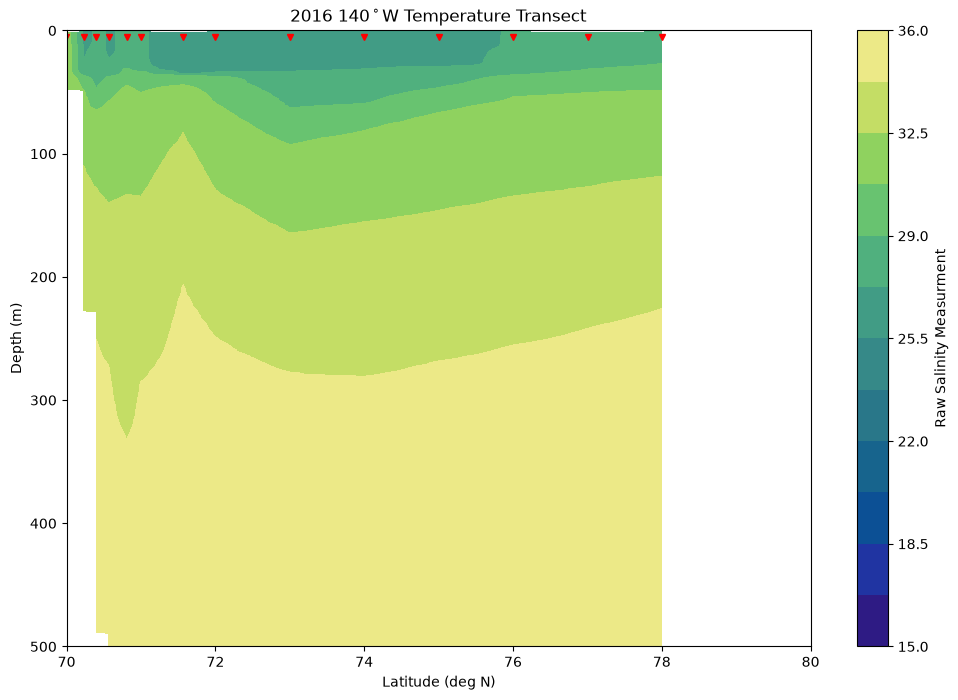

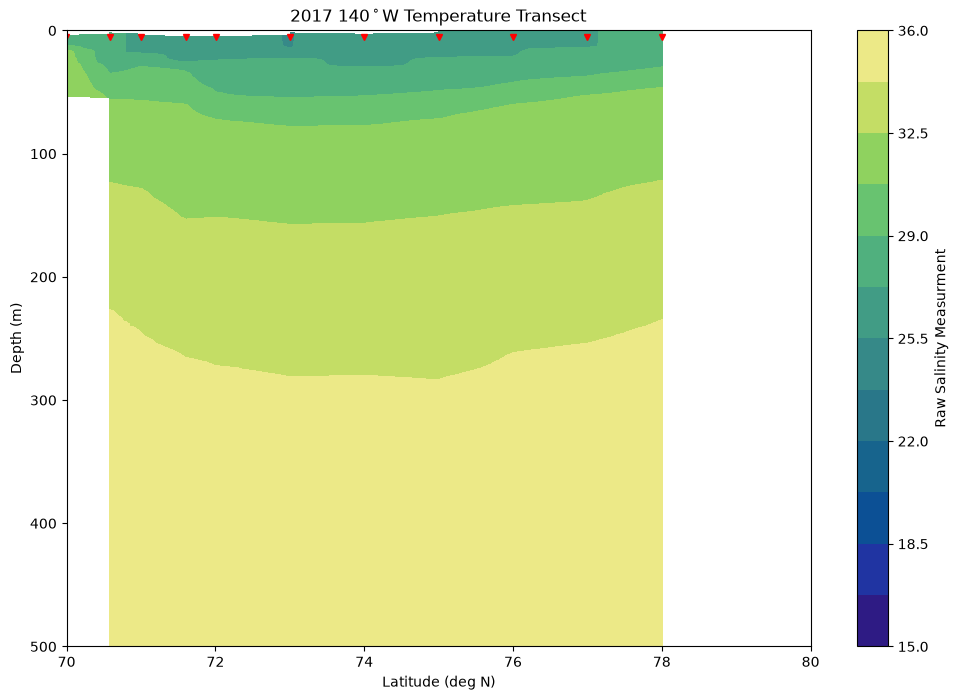

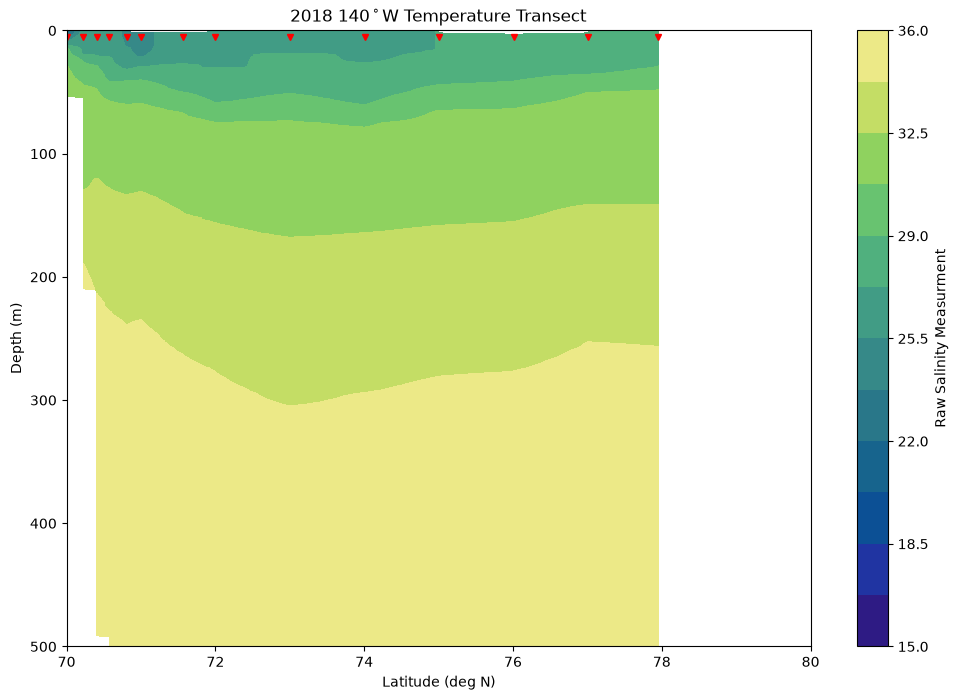

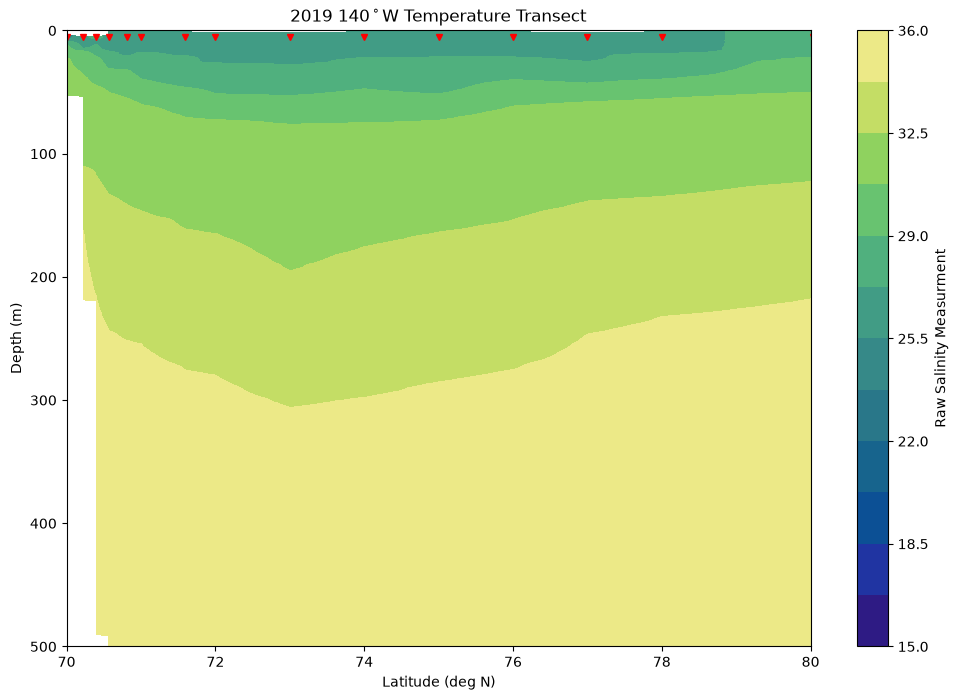

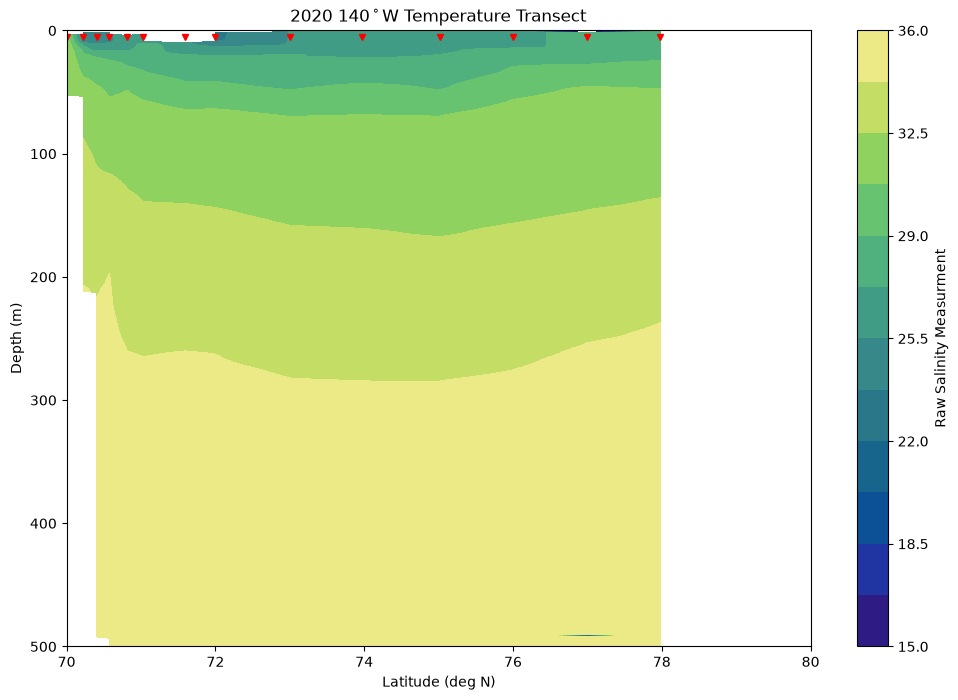

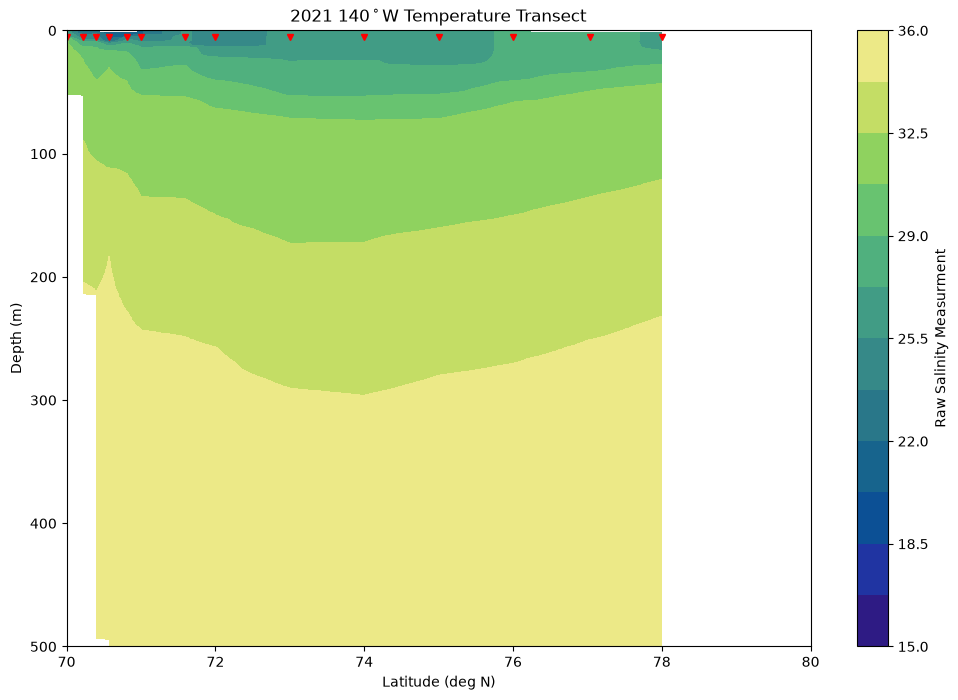

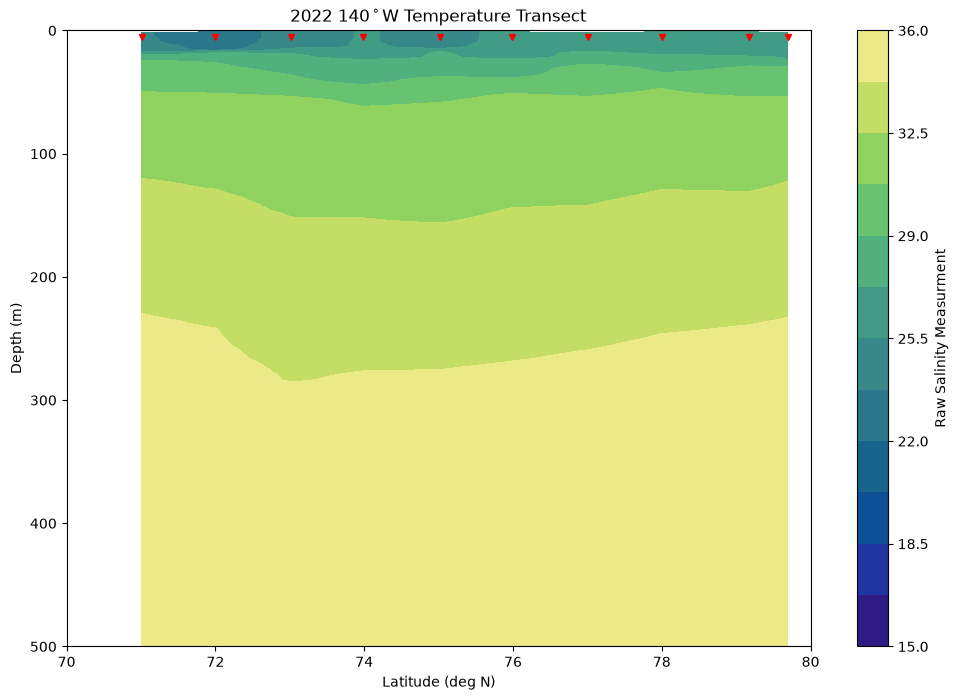

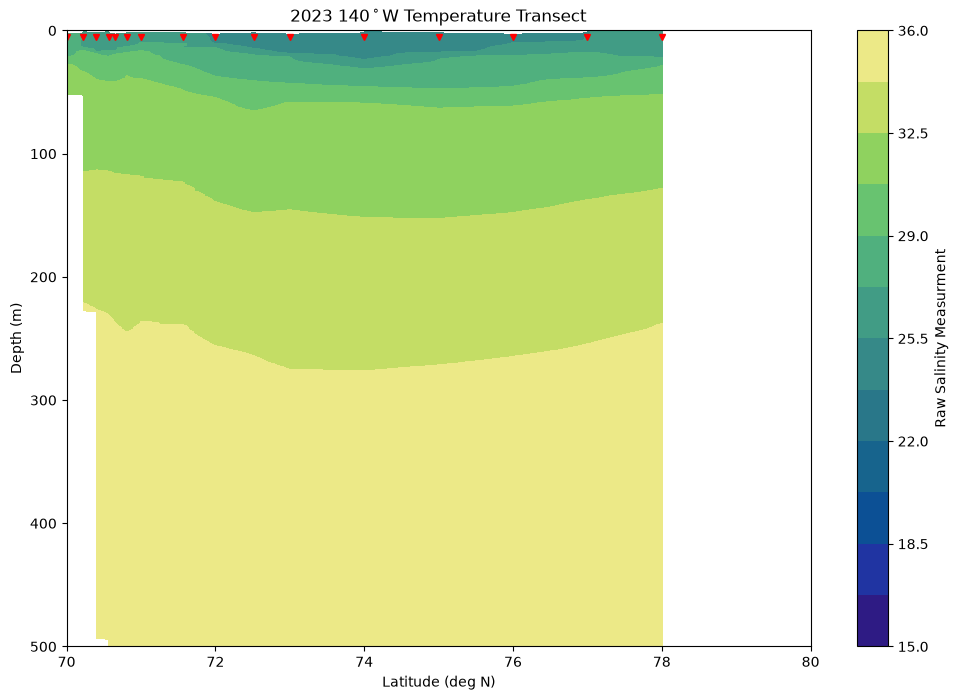

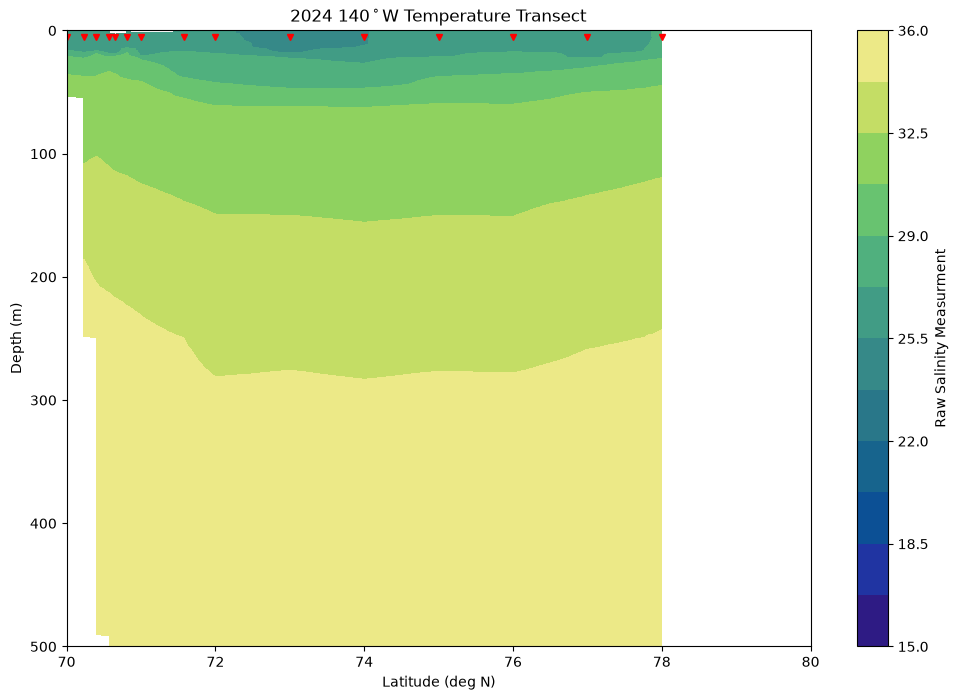

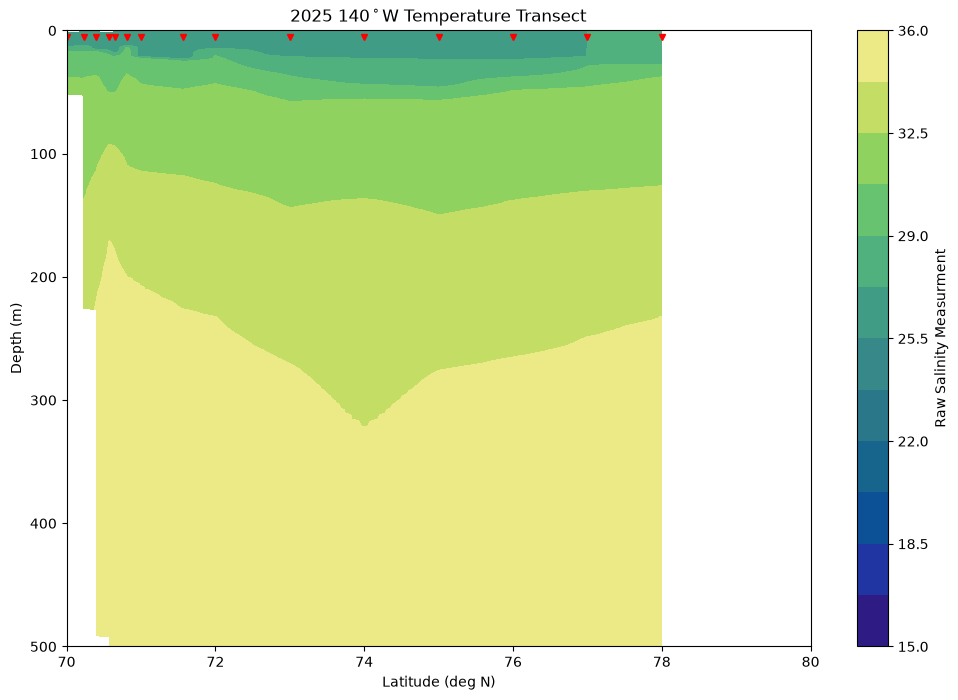

In [143]:
for cruise in e_ns_cruise_transects.keys():
    year = cruise
    transect = e_ns_cruise_transects[year].sortby(e_ns_cruise_transects[year]['lat'])
    field_figure = plt.figure(figsize=(12,8))
    ax = field_figure.add_subplot(1,1,1) 

    plotter.plot_custom_section(
        ds=transect,
        x = 'lat',
        y = 'depth',
        data = 'sal',
        fig = field_figure,
        ax = ax,
        cmap = cm.haline,
        cbar_label = 'Raw Salinity Measurment',
        levels=np.linspace(15,36,13)
        
    )

    plotter.plot_cast_locations(
        locations=transect['lat'],
        fig = field_figure,
        ax = ax,
        color = 'r',
        depth=5
    )

    ax.set_xlabel("Latitude (deg N)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"{year} 140$^\circ$W Temperature Transect")
    ax.set_ylim(top = 0, bottom=500)
    ax.set_xlim(left = 70, right = 80)

    plt.savefig(f"{year}_haline_contour")



lats = transect['lat']